# Лабораторная работа

**Датасет:** Digits — рукописные цифры (sklearn.datasets.load_digits)
- Признаки: 64 числовых признака (пиксели изображений 8×8)
- Классы: 10 классов (цифры 0–9)
- Объектов: 1797

In [1]:
import numpy as np
import pandas as pd
from itertools import cycle, islice

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    silhouette_score,
)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)

## 1. Выбор и изучение датасета

Используем датасет **Digits** из sklearn. Каждая строка — вектор из 64 числовых признаков (яркость пикселей). Целевая переменная — цифра (0–9).

In [2]:
digits = datasets.load_digits()
X_raw = digits.data
y_true = digits.target

print(f"Размер матрицы признаков X: {X_raw.shape}")
print(f"Количество классов: {len(np.unique(y_true))}")
print(f"Классы: {np.unique(y_true)}")
print(f"Распределение по классам:\n{pd.Series(y_true).value_counts().sort_index()}")

Размер матрицы признаков X: (1797, 64)
Количество классов: 10
Классы: [0 1 2 3 4 5 6 7 8 9]
Распределение по классам:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


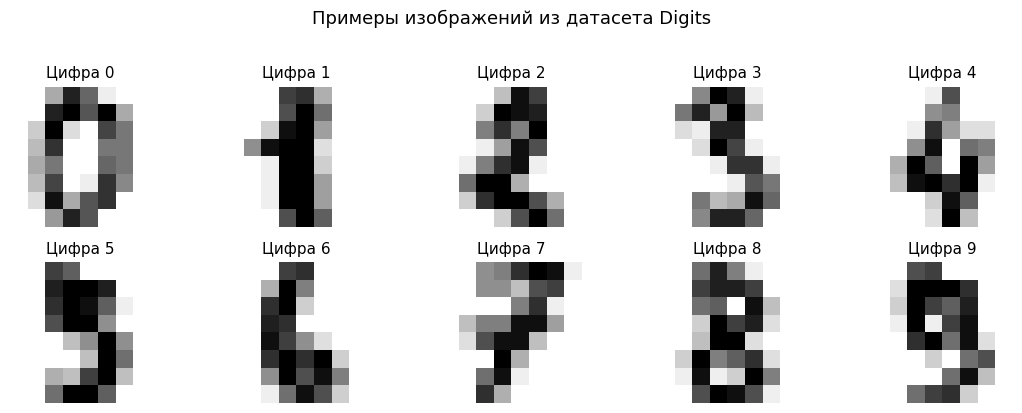

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_true == digit)[0][0]
    ax.imshow(X_raw[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {digit}', fontsize=11)
    ax.axis('off')
plt.suptitle('Примеры изображений из датасета Digits', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Формирование датасета D1

Датасет **D1** содержит 64 признака (без целевой переменной), нормализованных с помощью StandardScaler.

In [4]:
scaler = StandardScaler()
D1 = scaler.fit_transform(X_raw)

print(f"Размер D1: {D1.shape}")
print(f"Среднее: {D1.mean():.6f}")
print(f"Std: {D1.std():.6f}")

Размер D1: (1797, 64)
Среднее: 0.000000
Std: 0.976281


## 3. Снижение размерности: PCA → D2

Метод главных компонент (PCA) ищет направления максимального разброса данных. Снижаем D1 (64 признака) до 2 главных компонент.

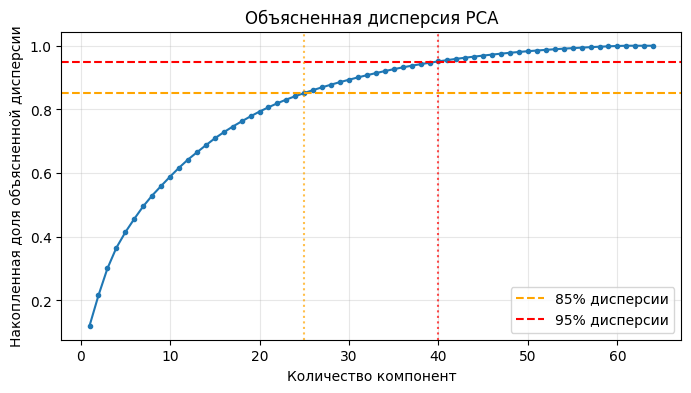

Для 85% дисперсии нужно 25 компонент
Для 95% дисперсии нужно 40 компонент


In [5]:
pca_full = PCA().fit(D1)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained)+1), explained, marker='o', markersize=3, linewidth=1.5)
plt.axhline(0.85, color='orange', linestyle='--', label='85% дисперсии')
plt.axhline(0.95, color='red',    linestyle='--', label='95% дисперсии')
n85 = np.argmax(explained >= 0.85) + 1
n95 = np.argmax(explained >= 0.95) + 1
plt.axvline(n85, color='orange', linestyle=':', alpha=0.7)
plt.axvline(n95, color='red',    linestyle=':', alpha=0.7)
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('Объясненная дисперсия PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Для 85% дисперсии нужно {n85} компонент")
print(f"Для 95% дисперсии нужно {n95} компонент")

In [6]:
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1)

print(f"Размер D2: {D2.shape}")
print(f"Доля объясненной дисперсии PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Доля объясненной дисперсии PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарная объясненная дисперсия: {np.sum(pca.explained_variance_ratio_):.3f}")

Размер D2: (1797, 2)
Доля объясненной дисперсии PC1: 0.120
Доля объясненной дисперсии PC2: 0.096
Суммарная объясненная дисперсия: 0.216


## 4. Снижение размерности: t-SNE → D3

Алгоритм t-SNE (t-distributed Stochastic Neighbor Embedding) сохраняет локальную структуру данных: объекты, близкие в исходном пространстве, остаются близкими после снижения размерности.

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
D3 = tsne.fit_transform(D1)

print(f"Размер D3: {D3.shape}")

Размер D3: (1797, 2)


## 5. Визуализация D2 и D3

Окрашиваем точки по истинным меткам классов (цифрам), чтобы оценить, насколько хорошо методы разделяют классы в 2D.

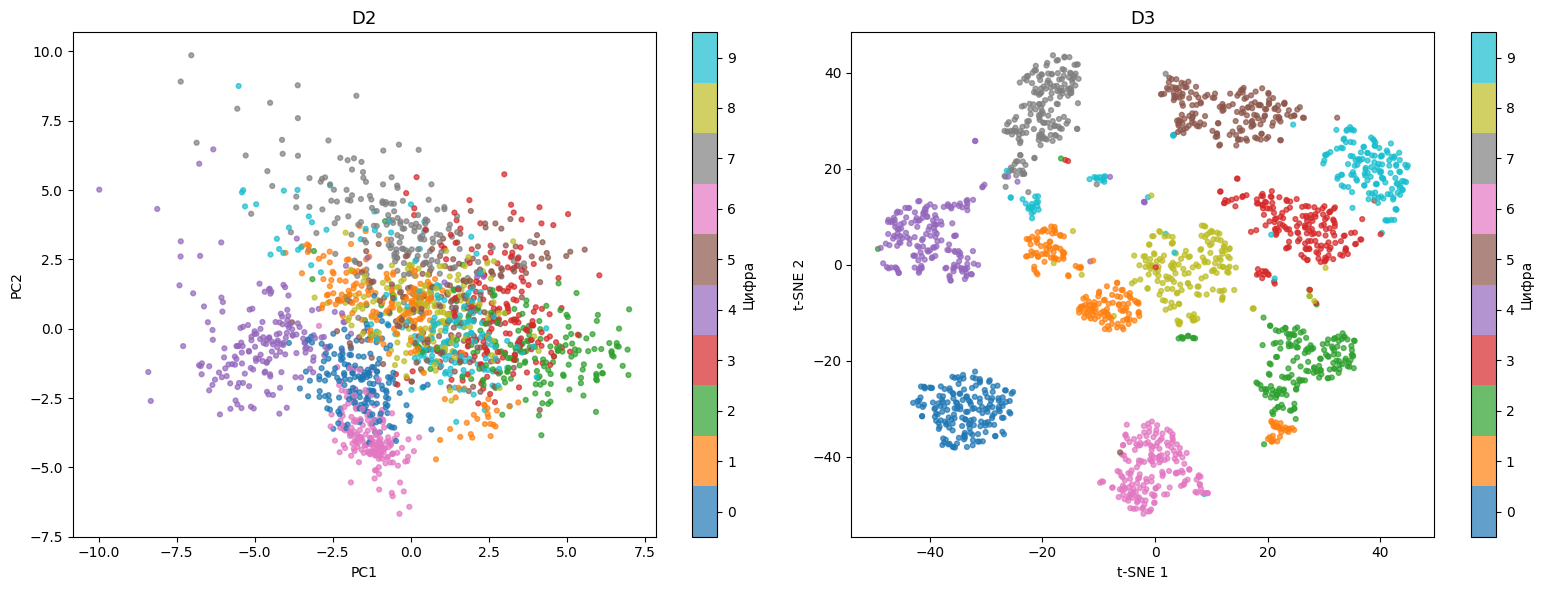

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(D2[:, 0], D2[:, 1], c=y_true, cmap='tab10', vmin=-0.5, vmax=9.5, alpha=0.7, s=12)
axes[0].set_title('D2', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], ticks=range(10), label='Цифра')

sc2 = axes[1].scatter(D3[:, 0], D3[:, 1], c=y_true, cmap='tab10', vmin=-0.5, vmax=9.5, alpha=0.7, s=12)
axes[1].set_title('D3', fontsize=13)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], ticks=range(10), label='Цифра')

plt.tight_layout()
plt.show()

### Вывод по визуализации

- **PCA (D2):** классы частично разделены, но сильно перекрываются — PCA сохраняет лишь ~22% дисперсии при 2 компонентах, что недостаточно для 64-мерных данных.
- **t-SNE (D3):** классы образуют чёткие, хорошо разделённые кластеры с минимальным перекрытием. t-SNE лучше сохраняет локальную структуру данных и значительно выразительнее для визуализации.

**В D3 кластеры выделены наиболее явно.**

## 6. Кластеризация датасетов D1, D2, D3

In [9]:
N_CLUSTERS = 10

def cluster_and_plot(D_cluster, y_true, method, title, ax, D_vis=None):
    labels = method.fit_predict(D_cluster)
    # Используем первые 2 измерения для отображения
    D_vis = D_vis if D_vis is not None else D_cluster
    colors = np.array(list(islice(
        cycle(['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
               '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']),
        int(max(labels)+2)
    )))
    ax.scatter(D_vis[:, 0], D_vis[:, 1], c=colors[labels], s=6, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return labels


def compute_metrics(D, y_true, method):
    labels = method.fit_predict(D)

    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    h, c, v = homogeneity_completeness_v_measure(y_true, labels)

    try:
        sil = silhouette_score(D, labels) if len(set(labels)) > 1 else float('nan')
    except Exception:
        sil = float('nan')

    return {
        'ARI': round(ari, 4),
        'AMI': round(ami, 4),
        'Homogeneity': round(h, 4),
        'Completeness': round(c, 4),
        'V-measure': round(v, 4),
        'Silhouette': round(sil, 4) if not np.isnan(sil) else 'N/A',
    }

print("Количество целевых кластеров:", N_CLUSTERS)

Количество целевых кластеров: 10


### 6.1 Метод k-средних (KMeans)

Классический алгоритм, разбивающий данные на K кластеров путём минимизации суммы квадратов расстояний от точек до центроидов кластеров.

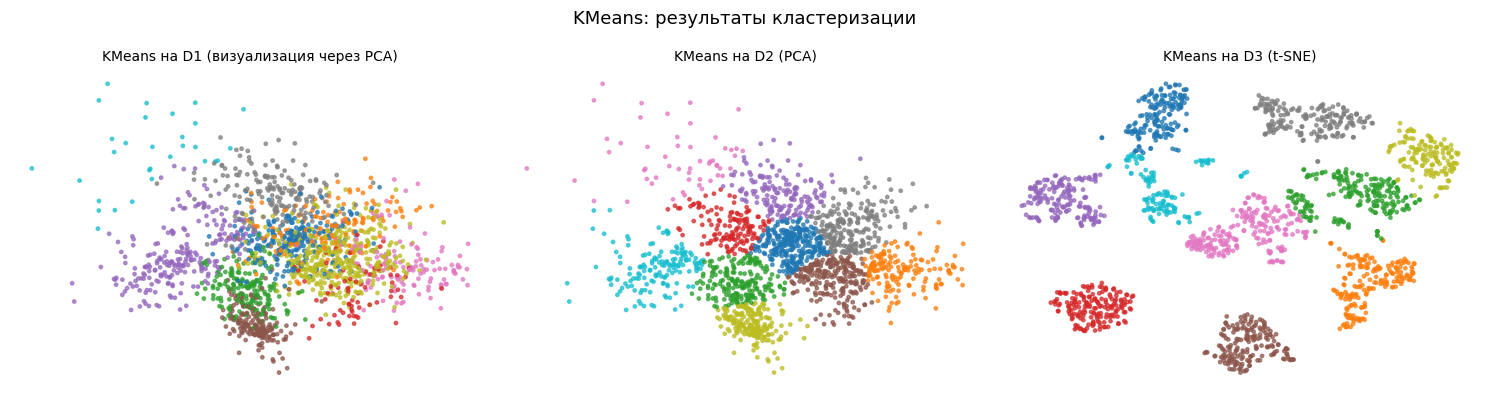

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels_km_D1 = cluster_and_plot(D1, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10), 'KMeans на D1 (визуализация через PCA)', axes[0], D_vis=D2)
labels_km_D2 = cluster_and_plot(D2, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10), 'KMeans на D2 (PCA)', axes[1])
labels_km_D3 = cluster_and_plot(D3, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10), 'KMeans на D3 (t-SNE)', axes[2])

plt.suptitle('KMeans: результаты кластеризации', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
km_method = KMeans(n_clusters=N_CLUSTERS, init='k-means++', random_state=42, n_init=10)
metrics_km = pd.DataFrame({
    'D1': compute_metrics(D1, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)),
    'D2': compute_metrics(D2, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)),
    'D3': compute_metrics(D3, y_true, KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)),
}).T
print("Метрики KMeans")
display(metrics_km)

Метрики KMeans


,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
D1,0.5344,0.6678,0.6498,0.6941,0.6712,0.1394
D2,0.3259,0.4591,0.4583,0.4709,0.4645,0.3778
D3,0.7692,0.8311,0.8305,0.8351,0.8328,0.5748


### 6.2 Иерархическая кластеризация (AgglomerativeClustering)

Агломеративный метод: начинает с каждого объекта как с отдельного кластера и последовательно объединяет наиболее близкие кластеры, пока не останется нужное число.

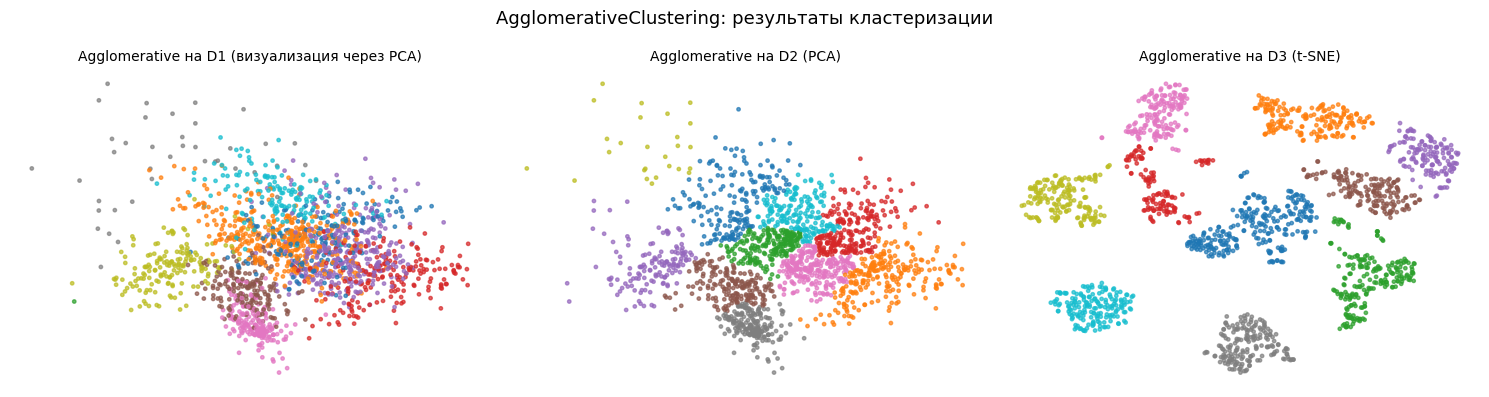

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cluster_and_plot(D1, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS), 'Agglomerative на D1 (визуализация через PCA)', axes[0], D_vis=D2)
cluster_and_plot(D2, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS), 'Agglomerative на D2 (PCA)', axes[1])
cluster_and_plot(D3, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS), 'Agglomerative на D3 (t-SNE)', axes[2])

plt.suptitle('AgglomerativeClustering: результаты кластеризации', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
metrics_agg = pd.DataFrame({
    'D1': compute_metrics(D1, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS)),
    'D2': compute_metrics(D2, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS)),
    'D3': compute_metrics(D3, y_true, AgglomerativeClustering(n_clusters=N_CLUSTERS)),
}).T
print("Метрики AgglomerativeClustering")
display(metrics_agg)

Метрики AgglomerativeClustering


,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
D1,0.6643,0.7935,0.7585,0.8365,0.7956,0.1253
D2,0.3099,0.4452,0.4437,0.4583,0.4509,0.3113
D3,0.7816,0.8415,0.8394,0.8469,0.8431,0.5689


### 6.3 Gaussian Mixture Model (GMM)

Вероятностная модель, предполагающая, что данные порождены смесью гауссовых распределений. Мягкая кластеризация — каждая точка принадлежит кластеру с определённой вероятностью.

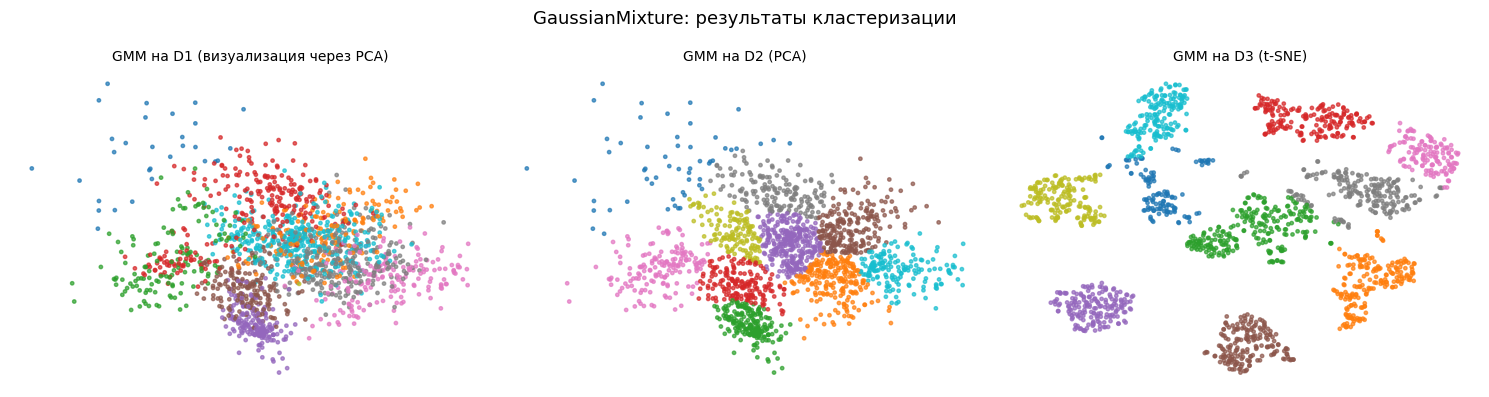

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cluster_and_plot(D1, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42, covariance_type='full'), 'GMM на D1 (визуализация через PCA)', axes[0], D_vis=D2)
cluster_and_plot(D2, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42, covariance_type='full'), 'GMM на D2 (PCA)', axes[1])
cluster_and_plot(D3, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42, covariance_type='full'), 'GMM на D3 (t-SNE)', axes[2])

plt.suptitle('GaussianMixture: результаты кластеризации', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
metrics_gmm = pd.DataFrame({
    'D1': compute_metrics(D1, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42)),
    'D2': compute_metrics(D2, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42)),
    'D3': compute_metrics(D3, y_true, GaussianMixture(n_components=N_CLUSTERS, random_state=42)),
}).T
print("Метрики GaussianMixture")
display(metrics_gmm)

Метрики GaussianMixture


,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
D1,0.5467,0.6870,0.6570,0.7268,0.6902,0.1179
D2,0.3276,0.4622,0.4610,0.4744,0.4676,0.3588
D3,0.7904,0.8443,0.8425,0.8493,0.8459,0.5684


## 7. Сводная таблица метрик

In [16]:
all_metrics = []

methods_config = [
    ('KMeans', KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)),
    ('AgglomerativeClustering', AgglomerativeClustering(n_clusters=N_CLUSTERS)),
    ('GaussianMixture', GaussianMixture(n_components=N_CLUSTERS, random_state=42)),
]

datasets_map = {'D1': D1, 'D2': D2, 'D3': D3}

rows = []
for method_name, method in methods_config:
    for ds_name, D in datasets_map.items():
        import copy
        m = copy.deepcopy(method)
        metrics = compute_metrics(D, y_true, m)
        rows.append({'Метод': method_name, 'Датасет': ds_name, **metrics})

summary = pd.DataFrame(rows)
display(summary)

,Метод,Датасет,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,KMeans,D1,0.5344,0.6678,0.6498,0.6941,0.6712,0.1394
1,KMeans,D2,0.3259,0.4591,0.4583,0.4709,0.4645,0.3778
2,KMeans,D3,0.7692,0.8311,0.8305,0.8351,0.8328,0.5748
3,AgglomerativeClustering,D1,0.6643,0.7935,0.7585,0.8365,0.7956,0.1253
4,AgglomerativeClustering,D2,0.3099,0.4452,0.4437,0.4583,0.4509,0.3113
5,AgglomerativeClustering,D3,0.7816,0.8415,0.8394,0.8469,0.8431,0.5689
6,GaussianMixture,D1,0.5467,0.6870,0.6570,0.7268,0.6902,0.1179
7,GaussianMixture,D2,0.3276,0.4622,0.4610,0.4744,0.4676,0.3588
8,GaussianMixture,D3,0.7904,0.8443,0.8425,0.8493,0.8459,0.5684


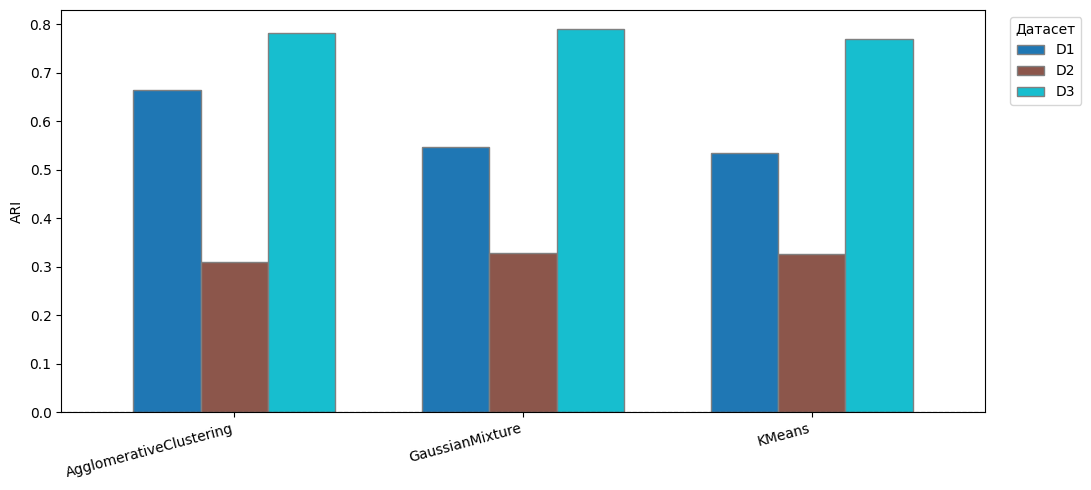

In [17]:
ari_pivot = summary.pivot(index='Метод', columns='Датасет', values='ARI').astype(float)

ax = ari_pivot.plot(kind='bar', figsize=(11, 5), colormap='tab10', width=0.7, edgecolor='gray')
ax.set_ylabel('ARI')
ax.set_xlabel('')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(title='Датасет', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

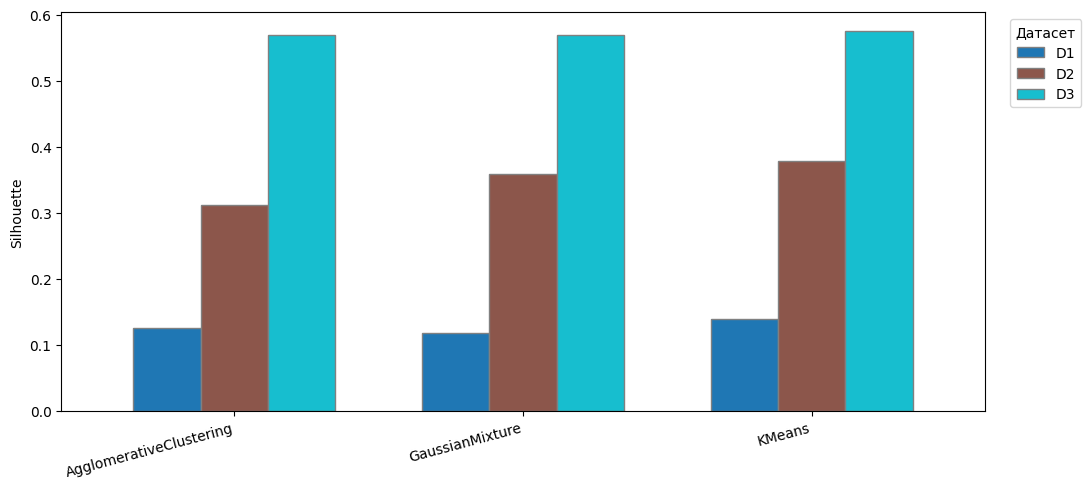

In [18]:
sil_pivot = summary.pivot(index='Метод', columns='Датасет', values='Silhouette')
sil_pivot = sil_pivot.apply(pd.to_numeric, errors='coerce')

ax2 = sil_pivot.plot(kind='bar', figsize=(11, 5), colormap='tab10', width=0.7, edgecolor='gray')
ax2.set_ylabel('Silhouette')
ax2.set_xlabel('')
ax2.legend(title='Датасет', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 8. Выводы

**Датасет D1 (исходные 64 признака).**
Наиболее эффективным оказался метод **AgglomerativeClustering** (ARI ≈ 0,66), так как он не привязан к форме кластеров и лучше находит структуру в 64-мерном пространстве.

**Датасет D2 (PCA, 2 компоненты).**
При PCA-сжатии до двух компонент и потере ~78% дисперсии наибольшую точность показал **GaussianMixture** (ARI ≈ 0,33), незначительно опередив KMeans. В отличие от них, метод AgglomerativeClustering оказался менее устойчив к размытию границ, возникающему при столь существенной потере информации.

**Датасет D3 (t-SNE, 2 компоненты).**
Наилучший результат показал **GaussianMixture** (ARI ≈ 0,79). Нелинейное снижение размерности t-SNE формирует компактные, хорошо разделённые группы, близкие по форме к гауссовым облакам, что создаёт оптимальные условия для вероятностной модели смеси распределений. Также важно отметить, что в данном случае все три метода демонстрируют высокое качество кластеризации.